# 01 - Data Overview and Quality Checks

This notebook explores:
- reefer data volume and temporal coverage
- target timestamp coverage
- missing-value and distribution checks
- first-pass aggregate load visualization

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path.cwd().resolve().parents[1] if (Path.cwd().name == "data_visualization") else Path.cwd().resolve().parents[0]
# Fallback: set explicit project root when running from notebook directory
if not (ROOT / "participant_package").exists():
    ROOT = Path("/Users/omkarsomeshwarkondhalkar/Movies/project/eurogate")

DATA_DIR = ROOT / "participant_package"
REEFER_PATH = DATA_DIR / "reefer_release.csv"
TARGET_PATH = DATA_DIR / "target_timestamps.csv"

print("ROOT:", ROOT)
print("REEFER_PATH exists:", REEFER_PATH.exists())
print("TARGET_PATH exists:", TARGET_PATH.exists())

ROOT: /Users/omkarsomeshwarkondhalkar/Movies/project/eurogate
REEFER_PATH exists: True
TARGET_PATH exists: True


In [2]:
# This file is semicolon-separated, so we first inspect available headers safely.
header_df = pd.read_csv(REEFER_PATH, sep=";", nrows=0)
available_cols = list(header_df.columns)
print("Available reefer columns:", available_cols)

preferred_cols = [
    "container_visit_uuid", "customer_uuid", "container_uuid", "HardwareType", "EventTime",
    "AvPowerCons", "TtlEnergyConsHour", "TtlEnergyCons", "TemperatureSetPoint",
    "TemperatureAmbient", "TemperatureReturn", "RemperatureSupply", "ContainerSize", "stack_tier"
]

use_cols = [c for c in preferred_cols if c in available_cols]
missing_cols = [c for c in preferred_cols if c not in available_cols]

print("Using columns:", use_cols)
print("Missing columns (safe to ignore if schema changed):", missing_cols)

df = pd.read_csv(
    REEFER_PATH,
    sep=";",
    usecols=use_cols,
    parse_dates=["EventTime"],
    low_memory=False,
)

targets = pd.read_csv(TARGET_PATH, parse_dates=["timestamp_utc"])

# Convert European decimal strings (e.g. "6,25") to float safely.
num_cols = ["AvPowerCons", "TtlEnergyConsHour", "TtlEnergyCons", "TemperatureSetPoint", "TemperatureAmbient", "TemperatureReturn", "RemperatureSupply"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

print("Reefer rows:", len(df))
print("Target rows:", len(targets))
print("Event range:", df["EventTime"].min(), "->", df["EventTime"].max())
print("Target range:", targets["timestamp_utc"].min(), "->", targets["timestamp_utc"].max())
print("Numeric non-null %:")
print((df[num_cols].notna().mean() * 100).round(2).to_dict())

df.head()

Available reefer columns: ['container_visit_uuid', 'customer_uuid', 'container_uuid', 'HardwareType', 'EventTime', 'AvPowerCons', 'TtlEnergyConsHour', 'TtlEnergyCons', 'TemperatureSetPoint', 'TemperatureAmbient', 'TemperatureReturn', 'RemperatureSupply', 'ContainerSize', 'stack_tier']
Using columns: ['container_visit_uuid', 'customer_uuid', 'container_uuid', 'HardwareType', 'EventTime', 'AvPowerCons', 'TtlEnergyConsHour', 'TtlEnergyCons', 'TemperatureSetPoint', 'TemperatureAmbient', 'TemperatureReturn', 'RemperatureSupply', 'ContainerSize', 'stack_tier']
Missing columns (safe to ignore if schema changed): []
Reefer rows: 3774557
Target rows: 223
Event range: 2025-01-01 00:00:00 -> 2026-01-10 06:00:00
Target range: 2026-01-01 00:00:00+00:00 -> 2026-01-10 06:00:00+00:00
Numeric non-null %:
{'AvPowerCons': 100.0, 'TtlEnergyConsHour': 100.0, 'TtlEnergyCons': 100.0, 'TemperatureSetPoint': 100.0, 'TemperatureAmbient': 100.0, 'TemperatureReturn': 100.0, 'RemperatureSupply': 100.0}


,container_visit_uuid,customer_uuid,container_uuid,HardwareType,EventTime,AvPowerCons,TtlEnergyConsHour,TtlEnergyCons,TemperatureSetPoint,TemperatureAmbient,TemperatureReturn,RemperatureSupply,ContainerSize,stack_tier
0,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 00:00:00,887.793488,887.437326,1.519376e+06,-18.0,9.625000,-18.100000,-19.950000,40.0,1.0
1,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 01:00:00,928.909479,928.094827,1.520305e+06,-18.0,10.066667,-18.000000,-19.900000,40.0,1.0
2,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 02:00:00,929.646456,929.299938,1.521234e+06,-18.0,10.250000,-17.975000,-19.850000,40.0,1.0
3,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 03:00:00,923.307627,925.736719,1.522160e+06,-18.0,10.550000,-17.900000,-19.800000,40.0,1.0
4,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 04:00:00,945.029192,944.842351,1.523104e+06,-18.0,11.066667,-17.833333,-19.766667,40.0,1.0


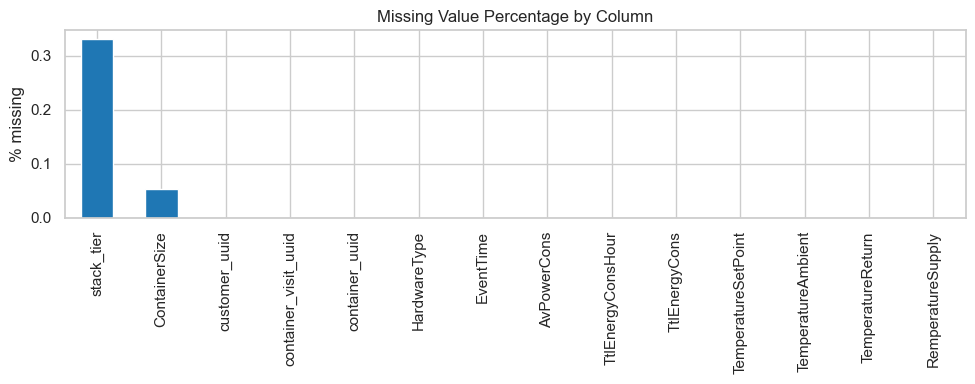

,missing_percent
stack_tier,0.330396
ContainerSize,0.052827
customer_uuid,0.000291
container_visit_uuid,0.000000
container_uuid,0.000000
HardwareType,0.000000
EventTime,0.000000
AvPowerCons,0.000000
TtlEnergyConsHour,0.000000
TtlEnergyCons,0.000000


In [3]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
missing_pct.plot(kind="bar", color="#1f77b4")
plt.title("Missing Value Percentage by Column")
plt.ylabel("% missing")
plt.tight_layout()
plt.show()

missing_pct.to_frame("missing_percent").head(20)

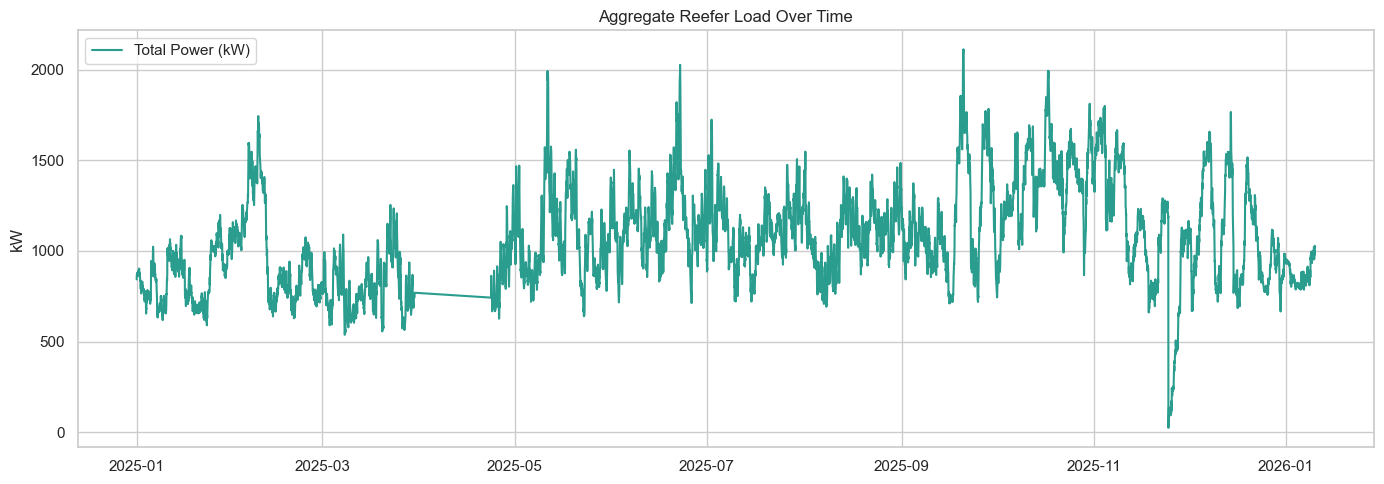

,EventTime,total_power_kw,reefer_count
0,2025-01-01 00:00:00,843.247345,425
1,2025-01-01 01:00:00,866.865919,425
2,2025-01-01 02:00:00,865.292780,425
3,2025-01-01 03:00:00,875.907910,425
4,2025-01-01 04:00:00,873.150000,425


In [4]:
# Support both old and new schema naming.
power_col = "AvPowerCons" if "AvPowerCons" in df.columns else "Power"
id_col = "container_visit_uuid" if "container_visit_uuid" in df.columns else "ContainerVisitID"

hourly = (
    df.assign(power_kw=df[power_col] / 1000.0)
      .groupby("EventTime", as_index=False)
      .agg(
          total_power_kw=("power_kw", "sum"),
          reefer_count=(id_col, "nunique")
      )
      .sort_values("EventTime")
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(hourly["EventTime"], hourly["total_power_kw"], label="Total Power (kW)", color="#2a9d8f")
ax1.set_ylabel("kW")
ax1.set_title("Aggregate Reefer Load Over Time")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.show()

hourly.head()

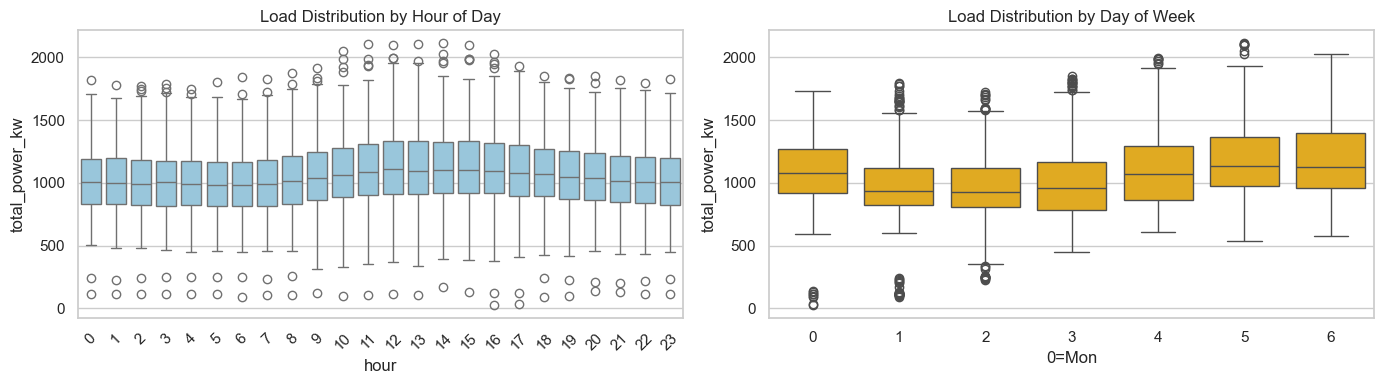

In [5]:
hourly["hour"] = hourly["EventTime"].dt.hour
hourly["dow"] = hourly["EventTime"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=hourly, x="hour", y="total_power_kw", ax=axes[0], color="#8ecae6")
axes[0].set_title("Load Distribution by Hour of Day")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=hourly, x="dow", y="total_power_kw", ax=axes[1], color="#ffb703")
axes[1].set_title("Load Distribution by Day of Week")
axes[1].set_xlabel("0=Mon")

plt.tight_layout()
plt.show()